In [1]:
import pandas as pd

file_path = "data_v1.csv"

df = pd.read_csv(file_path)

In [2]:
import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

def analyze_complexity_with_trend(df, level_order=("A1", "A2", "B1", "B2")):
    df = df[df["Level"].isin(level_order)].copy()
    level_map = {lvl: i for i, lvl in enumerate(level_order)}
    df["Level_idx"] = df["Level"].map(level_map)

    numeric_cols = df.select_dtypes(include=np.number).columns.drop(["Level_idx"], errors='ignore')
    results = []

    for col in numeric_cols:
        model = ols(f"{col} ~ C(Level, levels={list(level_order)})", data=df).fit()
        anova_table = sm.stats.anova_lm(model, typ=2)
        p_anova = anova_table["PR(>F)"][0]
        f_stat = anova_table["F"][0]

        # Linear Contrast Check
        trend_model = ols(f"{col} ~ Level_idx", data=df).fit()
        p_trend = trend_model.pvalues["Level_idx"]

        # Calculating averages for each level
        means = df.groupby("Level", observed=True)[col].mean().reindex(level_order)

        # Determining the trend direction
        direction = "Increasing" if means[level_order[-1]] > means[level_order[0]] else "Decreasing"

        results.append({
            "Feature": col,
            "F-Statistic": round(f_stat, 2),
            "ANOVA_P": round(p_anova, 4),
            "Trend_P": round(p_trend, 4),
            "Is_Monotonic": p_trend < 0.05,
            "Direction": direction,
            "Means (A1->B2)": [round(m, 2) for m in means.values]
        })

    return pd.DataFrame(results).sort_values("F-Statistic", ascending=False)

trend_report = analyze_complexity_with_trend(df)
print(trend_report)

/tmp/ipykernel_16740/1897117356.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_anova = anova_table["PR(>F)"][0]
/tmp/ipykernel_16740/1897117356.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  f_stat = anova_table["F"][0]
/tmp/ipykernel_16740/1897117356.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_anova = anova_table["PR(>F)"][0]
/tmp/ipykernel_16740/1897117356.py:19: FutureWarning: Series.__getitem__ treating 

                        Feature  F-Statistic  ANOVA_P  Trend_P  Is_Monotonic  \
26              avg_tree_depths        41.60   0.0000   0.0000          True   
5                hapax_legomena        39.78   0.0000   0.0000          True   
22   sentence_char_stats_median        38.03   0.0000   0.0000          True   
18  sentence_token_stats_median        37.09   0.0000   0.0000          True   
17    sentence_token_stats_mean        36.92   0.0000   0.0000          True   
4                 unique_lemmas        34.33   0.0000   0.0000          True   
21     sentence_char_stats_mean        33.83   0.0000   0.0000          True   
3                 unique_tokens        32.40   0.0000   0.0000          True   
16                 mattr_lemmas        31.74   0.0000   0.0000          True   
15                 mattr_tokens        27.96   0.0000   0.0000          True   
25                  avg_clauses        24.03   0.0000   0.0000          True   
20     sentence_token_stats_max        2

/tmp/ipykernel_16740/1897117356.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_anova = anova_table["PR(>F)"][0]
/tmp/ipykernel_16740/1897117356.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  f_stat = anova_table["F"][0]
/tmp/ipykernel_16740/1897117356.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_anova = anova_table["PR(>F)"][0]
/tmp/ipykernel_16740/1897117356.py:19: FutureWarning: Series.__getitem__ treating 

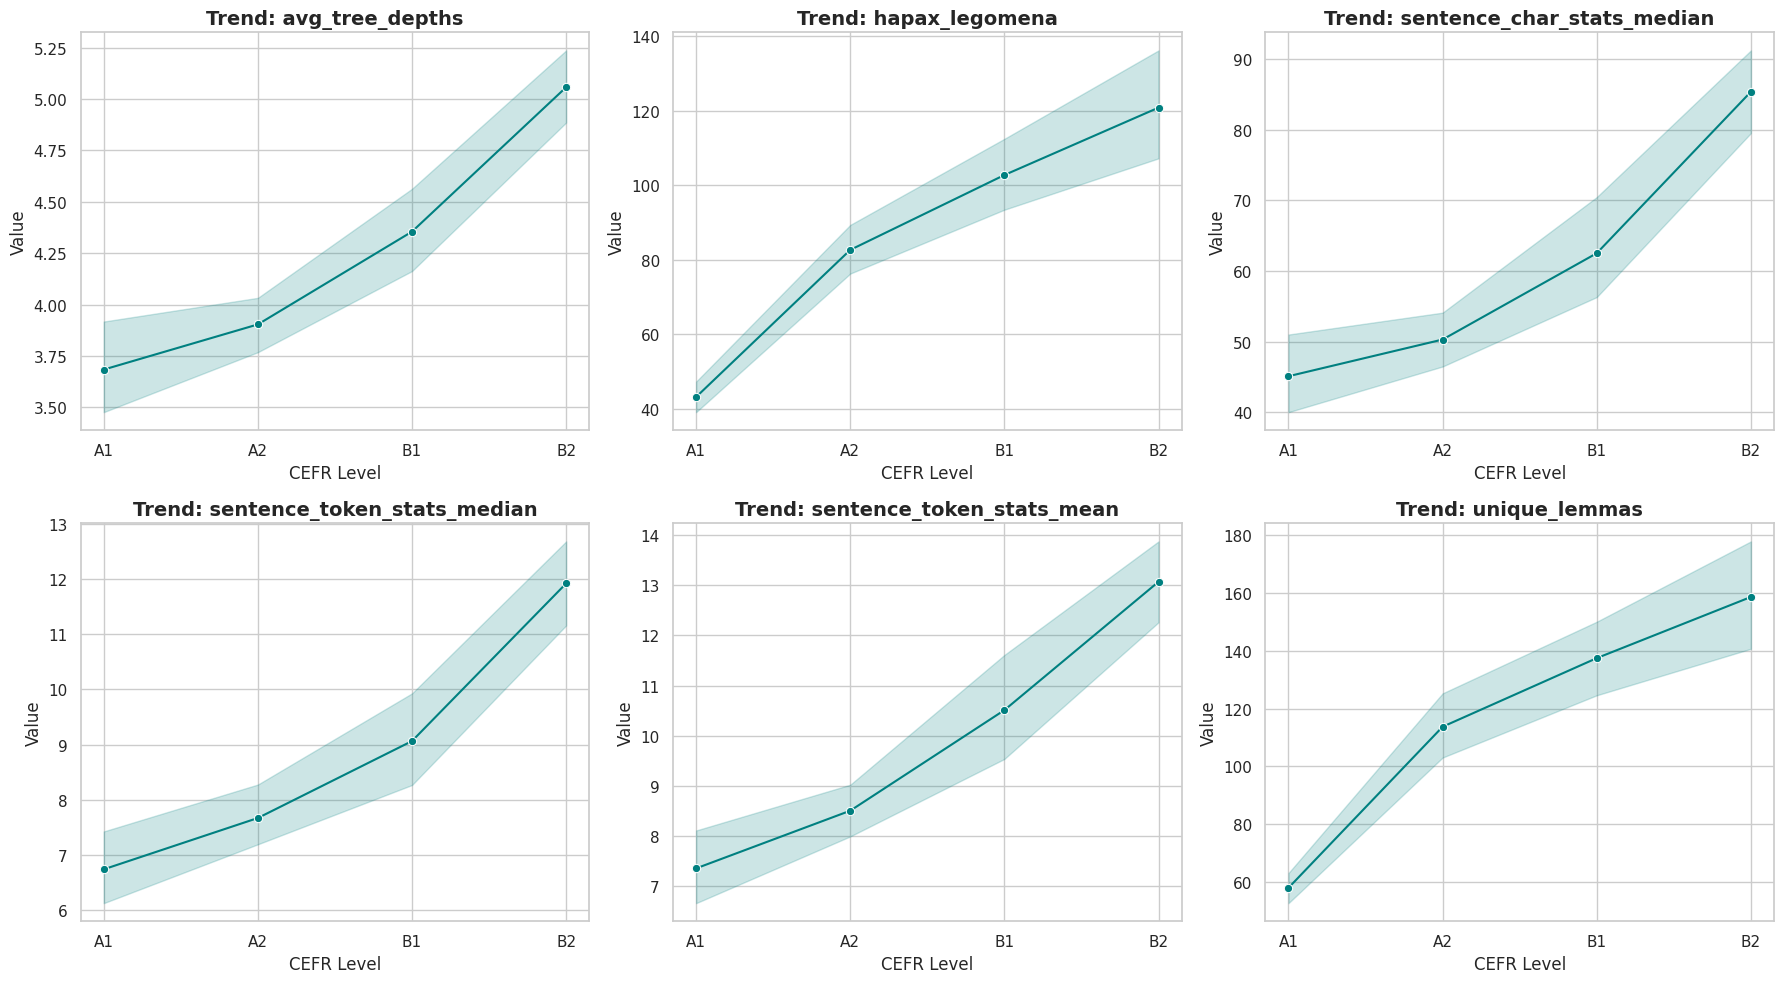

In [4]:
# visualization
import matplotlib.pyplot as plt
import seaborn as sns

top_features = trend_report.head(6)["Feature"].tolist()

plot_df = df[df["Level"].isin(["A1", "A2", "B1", "B2"])].copy()
plot_df["Level"] = pd.Categorical(plot_df["Level"], categories=["A1", "A2", "B1", "B2"], ordered=True)

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(top_features):
    sns.lineplot(data=plot_df, x="Level", y=col, ax=axes[i], marker="o", errorbar="ci", color="teal")
    axes[i].set_title(f"Trend: {col}", fontsize=14, fontweight='bold')
    axes[i].set_xlabel("CEFR Level")
    axes[i].set_ylabel("Value")

plt.tight_layout()
plt.show()